In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
auto_mpg = fetch_ucirepo(id=9) 
  
# data (as pandas dataframes) 
X = auto_mpg.data.features 
y = auto_mpg.data.targets 
  
# metadata 
print(auto_mpg.metadata) 
  
# variable information 
print(auto_mpg.variables) 


{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

## 1. Introduction

In [3]:
import pandas as pd
import numpy as np

# Combine the isolated target (y) and features (X) dataframes 
df = pd.concat([y, X], axis=1)

# Confirm the execution by inspecting the unified frame dimensions
print(f"Unified Data Frame Shape: {df.shape}")
df.head()

Unified Data Frame Shape: (398, 8)


,mpg,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,18.0,307.0,8,130.0,3504,12.0,70,1
1,15.0,350.0,8,165.0,3693,11.5,70,1
2,18.0,318.0,8,150.0,3436,11.0,70,1
3,16.0,304.0,8,150.0,3433,12.0,70,1
4,17.0,302.0,8,140.0,3449,10.5,70,1


## 2. Data Audit

In [4]:
# 1. Map the nominal integer codes to geographic strings for analytical readability
df['origin'] = df['origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})

# 2. Impute the horsepower missing values using the median value 
hp_median = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(hp_median)

# 3. Streamlined feature engineering to extract the raw car names and manufacturer brands
raw_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
df_text = pd.read_csv(raw_url, sep='"', header=None, names=['raw_metrics', 'car_name', 'extra'])
df['car_name'] = df_text['car_name']
df['brand'] = df['car_name'].str.split().str[0]

# 4. Standardize text inconsistencies and manufacturer entry typos
brand_corrections = {
    'chevy': 'chevrolet', 'chevroelt': 'chevrolet',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen', 'vw': 'volkswagen',
    'maxda': 'mazda'
}
df['brand'] = df['brand'].replace(brand_corrections)

# Final audit summary execution check
print("--- Missing Values Balance Check ---")
print(df.isnull().sum())
print("\n--- Verified Clean Manufacturer Brand Totals ---")
print(df['brand'].value_counts().head(10))

--- Missing Values Balance Check ---
mpg             0
displacement    0
cylinders       0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
brand           0
dtype: int64

--- Verified Clean Manufacturer Brand Totals ---
brand
ford          51
chevrolet     47
plymouth      31
amc           28
dodge         28
toyota        26
datsun        23
volkswagen    22
buick         17
pontiac       16
Name: count, dtype: int64


## 3. Methodology

In [5]:
# 1. Output basic numeric descriptions to evaluate skewness
print("--- Central Tendency & Distribution Summaries ---")
display(df.describe())

# 2. Re-establish the IQR outlier evaluation function
def find_outliers_numeric(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# 3. Iterate scanning through continuously bound metrics
print("\n--- Structural Boundary Outlier Scans ---")
for col in ['mpg', 'horsepower', 'displacement', 'weight']:
    outliers, low, high = find_outliers_numeric(df, col)
    print(f"{col.upper()}: Outliers Count = {len(outliers)} (Valid Range: {low:.1f} to {high:.1f})")

--- Central Tendency & Distribution Summaries ---


,mpg,displacement,cylinders,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,193.425879,5.454774,104.304020,2970.424623,15.568090,76.010050
std,7.815984,104.269838,1.701004,38.222625,846.841774,2.757689,3.697627
min,9.000000,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,104.250000,4.000000,76.000000,2223.750000,13.825000,73.000000
50%,23.000000,148.500000,4.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,262.000000,8.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000



--- Structural Boundary Outlier Scans ---
MPG: Outliers Count = 1 (Valid Range: 0.2 to 46.2)
HORSEPOWER: Outliers Count = 11 (Valid Range: 2.5 to 198.5)
DISPLACEMENT: Outliers Count = 0 (Valid Range: -132.4 to 498.6)
WEIGHT: Outliers Count = 0 (Valid Range: 147.4 to 5684.4)


## 4. Visualization

/var/folders/5r/f8y6t94d4199zn49r70sw0zw0000gn/T/ipykernel_22456/969716875.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='origin', y='horsepower', palette='Set2', width=0.5)


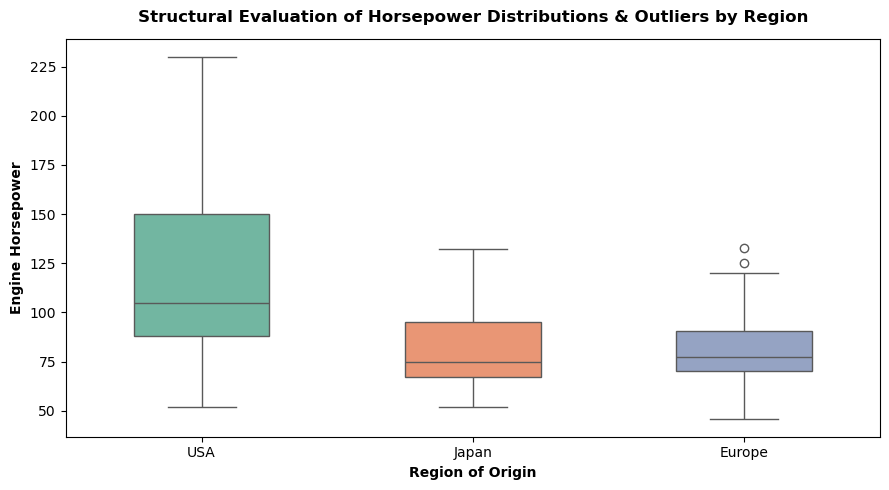

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a diagnostic boxplot for Horsepower grouped by Origin region
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='origin', y='horsepower', palette='Set2', width=0.5)

# Formal labeling with titles
plt.title('Structural Evaluation of Horsepower Distributions & Outliers by Region', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Region of Origin', fontsize=10, fontweight='bold')
plt.ylabel('Engine Horsepower', fontsize=10, fontweight='bold')
plt.tight_layout()

# Save as an intermediate diagnostic plot [cite: 59]
plt.savefig('horsepower_boxplot.png', dpi=150) # [cite: 59]
plt.show()

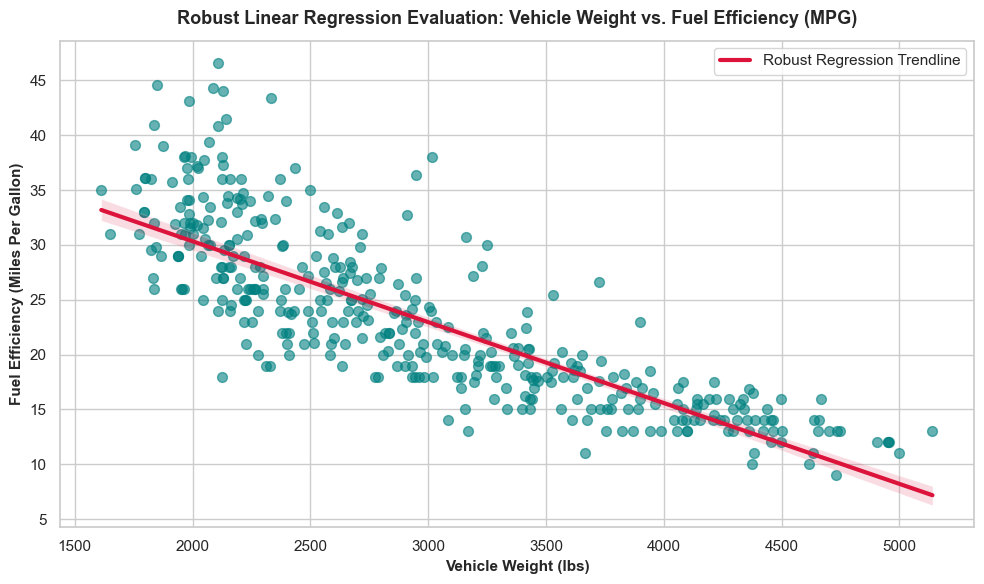

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional, clean grid background
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot a robust linear regression trendline that filters out outlier distortion
sns.regplot(
    data=df, 
    x='weight', 
    y='mpg', 
    robust=True, 
    scatter_kws={'alpha': 0.6, 's': 50, 'color': 'teal'}, 
    line_kws={'color': 'crimson', 'linewidth': 3, 'label': 'Robust Regression Trendline'}
)

# Apply formal labeling, titles, and mandatory units
plt.title('Robust Linear Regression Evaluation: Vehicle Weight vs. Fuel Efficiency (MPG)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Vehicle Weight (lbs)', fontsize=11, fontweight='bold')
plt.ylabel('Fuel Efficiency (Miles Per Gallon)', fontsize=11, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()

# Export at high-resolution for your PDF report
plt.savefig('robust_trendline.png', dpi=150)
plt.show()

## 5. Key Insight

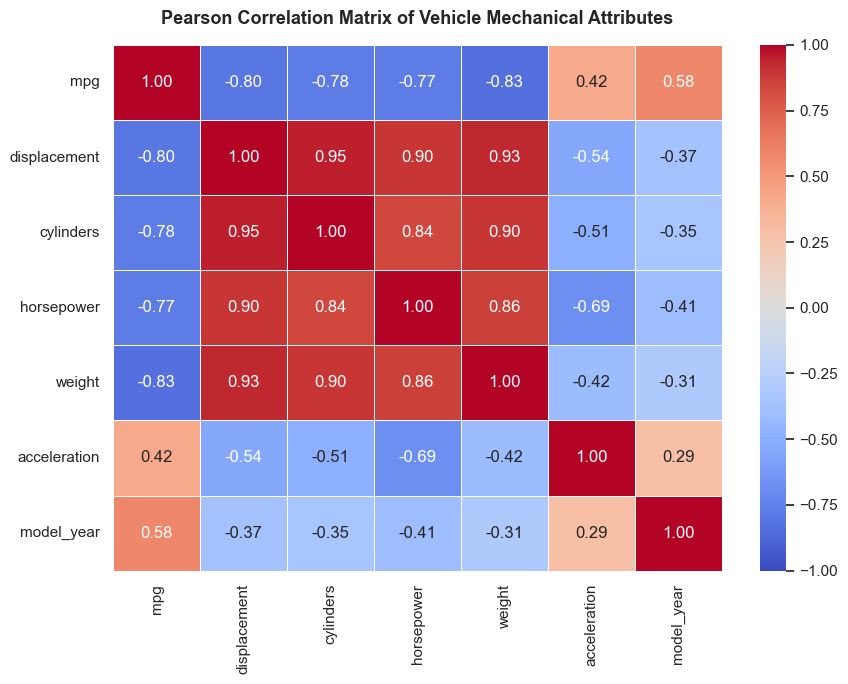

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Isolate only the numeric features for correlation analysis
# (This drops 'origin', 'car_name', and 'brand' so we can do math)
numeric_df = df.select_dtypes(include=[np.number])

# 2. Configure a clean, professional canvas size
plt.figure(figsize=(9, 7))

# 3. Plot the Pearson correlation matrix using a coolwarm color profile
sns.heatmap(
    numeric_df.corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)

# Apply formal business formatting and titles
plt.title('Pearson Correlation Matrix of Vehicle Mechanical Attributes', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

# 4. Export at 150 DPI for your official PDF report document
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

## 6. Conclusion 

In [9]:
# Save out the finished, transformed file matching project guidelines
df.to_csv('cleaned_auto_mpg_data.csv', index=False)
print("Data framework cleanly written out to disk!")

Data framework cleanly written out to disk!
